# Healthcare Management & Operations Analytics

### Hospital Management Analytics Project

This project analyzes hospital appointments, patient activity, doctor workload, treatments, and billing data to identify operational trends, risks, and actionable business insights.

**Analysis Type:** Descriptive & Diagnostic Analytics  
**Dataset:** Hospital Management Dataset


## 1. Import Libraries

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Dataset

In [108]:
# The dataset should be in the same folder as this notebook.
file_path = Path("healthcare_analysis_ready.csv")

if not file_path.exists():
    raise FileNotFoundError(
        "healthcare_analysis_ready.csv was not found. "
        "Place the CSV in the same folder as this notebook."
    )

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


Dataset loaded successfully.
Rows: 200
Columns: 38


## 3. Data Understanding

In [109]:
display(df.head())
print("\nDataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())


,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email,first_name_doctor,last_name_doctor,specialization,phone_number,years_experience,hospital_branch,email_doctor,treatment_id,treatment_type,description,cost,treatment_date,bill_id,patient_id_billing,bill_date,amount,payment_method,payment_status,appointment_month,appointment_day,appointment_day_name
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,Alex,Smith,F,1950-01-26,8374657733,321 Maple Dr,2023-06-18,WellnessCorp,INS653880,alex.smith@mail.com,Sarah,Smith,Pediatrics,7387087517,26,Central Hospital,dr.sarah.smith@hospital.com,T001,Chemotherapy,Basic screening,"3,941.97",2023-08-09,B001,P034,2023-08-09,"3,941.97",Insurance,Pending,2023-08,9,Wednesday
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show,Alex,Moore,M,1981-01-08,8102183595,123 Elm St,2021-10-02,MedCare Plus,INS335362,alex.moore@mail.com,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com,T002,MRI,Advanced protocol,"4,158.44",2023-06-09,B002,P032,2023-06-09,"4,158.44",Insurance,Paid,2023-06,9,Friday
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled,Emily,Miller,M,1983-03-24,8720989381,123 Elm St,2023-06-19,PulseSecure,INS694319,emily.miller@mail.com,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com,T003,MRI,Standard procedure,"3,731.55",2023-06-28,B003,P048,2023-06-28,"3,731.55",Insurance,Paid,2023-06,28,Wednesday
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled,Robert,Wilson,M,1966-08-14,7482069727,123 Elm St,2021-09-09,HealthIndia,INS833429,robert.wilson@mail.com,Alex,Davis,Pediatrics,6570137231,23,Central Hospital,dr.alex.davis@hospital.com,T004,MRI,Basic screening,"4,799.86",2023-09-01,B004,P025,2023-09-01,"4,799.86",Insurance,Failed,2023-09,1,Friday
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show,Emily,Williams,M,1972-05-30,7587653815,456 Oak Ave,2021-10-16,PulseSecure,INS320984,emily.williams@mail.com,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com,T005,ECG,Standard procedure,582.05,2023-07-06,B005,P040,2023-07-06,582.05,Credit Card,Pending,2023-07,6,Thursday



Dataset shape: (200, 38)

Column names:
['appointment_id', 'patient_id', 'doctor_id', 'appointment_date', 'appointment_time', 'reason_for_visit', 'status', 'first_name', 'last_name', 'gender', 'date_of_birth', 'contact_number', 'address', 'registration_date', 'insurance_provider', 'insurance_number', 'email', 'first_name_doctor', 'last_name_doctor', 'specialization', 'phone_number', 'years_experience', 'hospital_branch', 'email_doctor', 'treatment_id', 'treatment_type', 'description', 'cost', 'treatment_date', 'bill_id', 'patient_id_billing', 'bill_date', 'amount', 'payment_method', 'payment_status', 'appointment_month', 'appointment_day', 'appointment_day_name']


In [110]:
print("Data types:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("Missing Values"))

print("\nExact duplicate rows:", df.duplicated().sum())
print("Unique appointments:", df["appointment_id"].nunique())
print("Unique patients:", df["patient_id"].nunique())
print("Unique doctors:", df["doctor_id"].nunique())


Data types:


,Data Type
appointment_id,str
patient_id,str
doctor_id,str
appointment_date,str
appointment_time,str
reason_for_visit,str
status,str
first_name,str
last_name,str
gender,str



Missing values:


,Missing Values
appointment_id,0
patient_id,0
doctor_id,0
appointment_date,0
appointment_time,0
reason_for_visit,0
status,0
first_name,0
last_name,0
gender,0



Exact duplicate rows: 0
Unique appointments: 200
Unique patients: 48
Unique doctors: 10


## 4. Data Preparation

In [111]:
# Convert date columns
date_columns = [
    "appointment_date",
    "date_of_birth",
    "registration_date",
    "treatment_date",
    "bill_date"
]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Convert numeric columns
numeric_columns = ["cost", "amount", "years_experience"]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Clean text fields
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

# Create doctor name
if "doctor_name" not in df.columns:
    if {"first_name_doctor", "last_name_doctor"}.issubset(df.columns):
        df["doctor_name"] = (
            df["first_name_doctor"].fillna("")
            + " "
            + df["last_name_doctor"].fillna("")
        ).str.strip()
    else:
        df["doctor_name"] = df["doctor_id"].astype(str)

# Create useful date dimensions
df["appointment_month_num"] = df["appointment_date"].dt.month
df["appointment_month"] = df["appointment_date"].dt.strftime("%b")
df["appointment_day_name"] = df["appointment_date"].dt.day_name()

print("Data preparation completed.")
display(df.head(3))


Data preparation completed.


C:\Users\prita\AppData\Local\Temp\ipykernel_10232\1194316811.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include="object").columns


,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email,first_name_doctor,last_name_doctor,specialization,phone_number,years_experience,hospital_branch,email_doctor,treatment_id,treatment_type,description,cost,treatment_date,bill_id,patient_id_billing,bill_date,amount,payment_method,payment_status,appointment_month,appointment_day,appointment_day_name,doctor_name,appointment_month_num
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,Alex,Smith,F,1950-01-26,8374657733,321 Maple Dr,2023-06-18,WellnessCorp,INS653880,alex.smith@mail.com,Sarah,Smith,Pediatrics,7387087517,26,Central Hospital,dr.sarah.smith@hospital.com,T001,Chemotherapy,Basic screening,"3,941.97",2023-08-09,B001,P034,2023-08-09,"3,941.97",Insurance,Pending,Aug,9,Wednesday,Sarah Smith,8
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show,Alex,Moore,M,1981-01-08,8102183595,123 Elm St,2021-10-02,MedCare Plus,INS335362,alex.moore@mail.com,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com,T002,MRI,Advanced protocol,"4,158.44",2023-06-09,B002,P032,2023-06-09,"4,158.44",Insurance,Paid,Jun,9,Friday,David Jones,6
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled,Emily,Miller,M,1983-03-24,8720989381,123 Elm St,2023-06-19,PulseSecure,INS694319,emily.miller@mail.com,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com,T003,MRI,Standard procedure,"3,731.55",2023-06-28,B003,P048,2023-06-28,"3,731.55",Insurance,Paid,Jun,28,Wednesday,David Jones,6


## 5. Key Performance Indicators (KPIs)

In [112]:
total_appointments = len(df)

completed = (df["status"] == "Completed").sum()
cancelled = (df["status"] == "Cancelled").sum()
no_show = (df["status"] == "No-show").sum()
scheduled = (df["status"] == "Scheduled").sum()

total_billed = df["amount"].sum()
paid_amount = df.loc[df["payment_status"] == "Paid", "amount"].sum()
pending_amount = df.loc[df["payment_status"] == "Pending", "amount"].sum()
failed_amount = df.loc[df["payment_status"] == "Failed", "amount"].sum()

completion_rate = completed / total_appointments * 100
cancellation_rate = cancelled / total_appointments * 100
no_show_rate = no_show / total_appointments * 100

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Patients",
        "Total Doctors",
        "Total Appointments",
        "Completed Appointments",
        "Completion Rate (%)",
        "Cancellation Rate (%)",
        "No-show Rate (%)",
        "Total Billed (INR)",
        "Paid Amount (INR)",
        "Pending Amount (INR)",
        "Failed Amount (INR)"
    ],
    "Value": [
        df["patient_id"].nunique(),
        df["doctor_id"].nunique(),
        total_appointments,
        completed,
        round(completion_rate, 1),
        round(cancellation_rate, 1),
        round(no_show_rate, 1),
        round(total_billed, 2),
        round(paid_amount, 2),
        round(pending_amount, 2),
        round(failed_amount, 2)
    ]
})

display(kpi_summary)


,KPI,Value
0,Total Patients,48.00
1,Total Doctors,10.00
2,Total Appointments,200.00
3,Completed Appointments,46.00
4,Completion Rate (%),23.00
5,Cancellation Rate (%),25.50
6,No-show Rate (%),26.00
7,Total Billed (INR),"551,249.85"
8,Paid Amount (INR),"173,424.90"
9,Pending Amount (INR),"184,612.01"


## 6. Appointment Status Analysis

,Status,Appointments,Percentage (%)
0,No-show,52,26.00
1,Scheduled,51,25.50
2,Cancelled,51,25.50
3,Completed,46,23.00


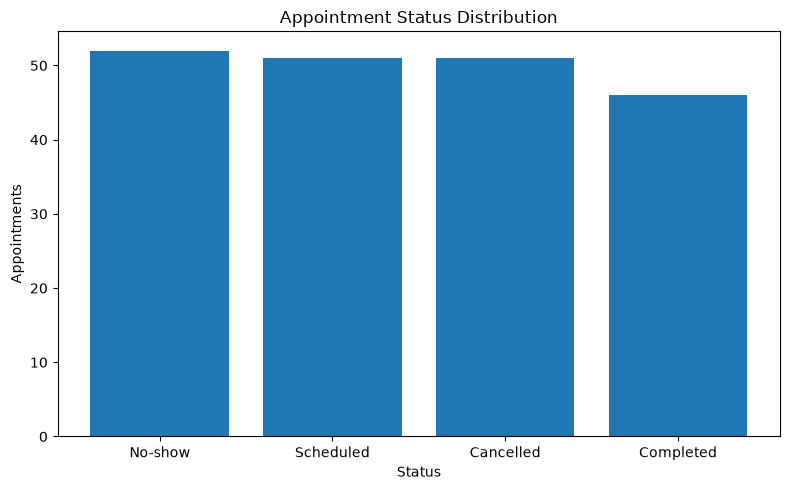

In [113]:
status_summary = (
    df["status"]
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Appointments")
)

status_summary["Percentage (%)"] = (
    status_summary["Appointments"] / len(df) * 100
).round(1)

display(status_summary)

plt.figure(figsize=(8, 5))
plt.bar(status_summary["Status"], status_summary["Appointments"])
plt.title("Appointment Status Distribution")
plt.xlabel("Status")
plt.ylabel("Appointments")
plt.tight_layout()
plt.show()


## 7. Branch Analysis

In [114]:
branch_analysis = pd.crosstab(df["hospital_branch"], df["status"])
branch_analysis["Total"] = branch_analysis.sum(axis=1)

for status in ["Completed", "Cancelled", "No-show", "Scheduled"]:
    if status not in branch_analysis.columns:
        branch_analysis[status] = 0
    branch_analysis[f"{status} %"] = (
        branch_analysis[status] / branch_analysis["Total"] * 100
    ).round(1)

branch_analysis = branch_analysis.reset_index()

display(branch_analysis)


status,hospital_branch,Cancelled,Completed,No-show,Scheduled,Total,Completed %,Cancelled %,No-show %,Scheduled %
0,Central Hospital,19,15,26,24,84,17.90,22.60,31.00,28.60
1,Eastside Clinic,15,16,13,18,62,25.80,24.20,21.00,29.00
2,Westside Clinic,17,15,13,9,54,27.80,31.50,24.10,16.70


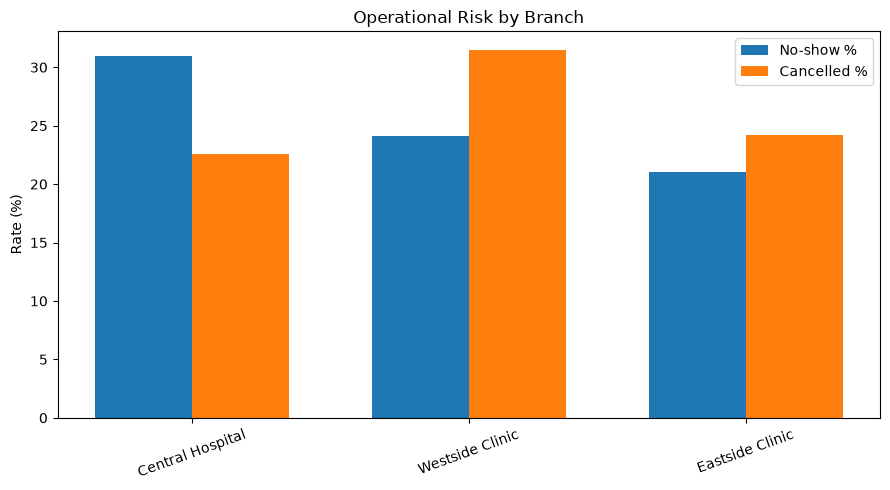

In [115]:
branch_plot = branch_analysis.sort_values("No-show %", ascending=False)

x = np.arange(len(branch_plot))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, branch_plot["No-show %"], width, label="No-show %")
plt.bar(x + width / 2, branch_plot["Cancelled %"], width, label="Cancelled %")
plt.xticks(x, branch_plot["hospital_branch"], rotation=20)
plt.ylabel("Rate (%)")
plt.title("Operational Risk by Branch")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Appointment Reason Analysis

In [116]:
reason_analysis = pd.crosstab(df["reason_for_visit"], df["status"])
reason_analysis["Total"] = reason_analysis.sum(axis=1)

for status in ["Completed", "Cancelled", "No-show", "Scheduled"]:
    if status not in reason_analysis.columns:
        reason_analysis[status] = 0
    reason_analysis[f"{status} %"] = (
        reason_analysis[status] / reason_analysis["Total"] * 100
    ).round(1)

reason_analysis = reason_analysis.reset_index()

display(reason_analysis)


status,reason_for_visit,Cancelled,Completed,No-show,Scheduled,Total,Completed %,Cancelled %,No-show %,Scheduled %
0,Checkup,8,16,10,11,45,35.60,17.80,22.20,24.40
1,Consultation,15,4,11,13,43,9.30,34.90,25.60,30.20
2,Emergency,8,5,10,6,29,17.20,27.60,34.50,20.70
3,Follow-up,10,12,6,13,41,29.30,24.40,14.60,31.70
4,Therapy,10,9,15,8,42,21.40,23.80,35.70,19.00


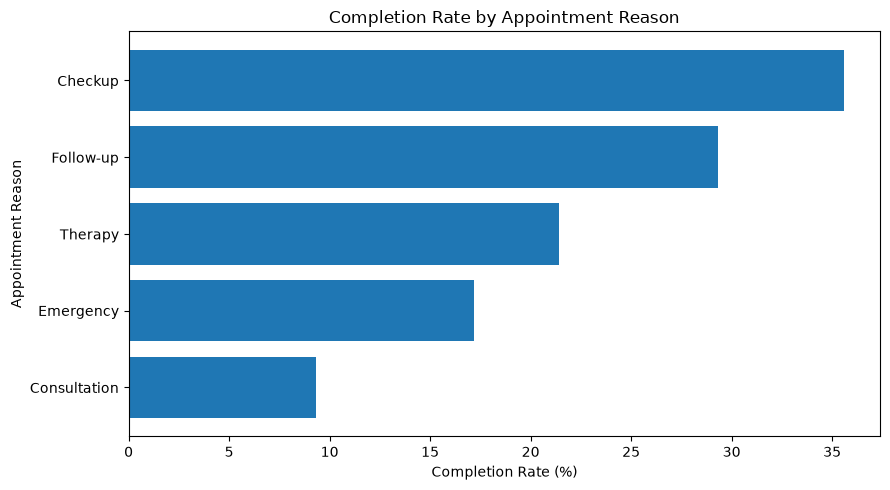

In [117]:
reason_plot = reason_analysis.sort_values("Completed %", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(reason_plot["reason_for_visit"], reason_plot["Completed %"])
plt.xlabel("Completion Rate (%)")
plt.ylabel("Appointment Reason")
plt.title("Completion Rate by Appointment Reason")
plt.tight_layout()
plt.show()


## 9. Specialization Analysis

In [118]:
specialization_analysis = pd.crosstab(
    df["specialization"],
    df["status"]
)

specialization_analysis["Total"] = specialization_analysis.sum(axis=1)

for status in ["Completed", "Cancelled", "No-show", "Scheduled"]:
    if status not in specialization_analysis.columns:
        specialization_analysis[status] = 0
    specialization_analysis[f"{status} %"] = (
        specialization_analysis[status]
        / specialization_analysis["Total"]
        * 100
    ).round(1)

specialization_analysis = specialization_analysis.reset_index()

display(specialization_analysis)


status,specialization,Cancelled,Completed,No-show,Scheduled,Total,Completed %,Cancelled %,No-show %,Scheduled %
0,Dermatology,18,14,20,18,70,20.00,25.70,28.60,25.70
1,Oncology,8,10,7,7,32,31.20,25.00,21.90,21.90
2,Pediatrics,25,22,25,26,98,22.40,25.50,25.50,26.50


## 10. Doctor Workload Analysis

In [119]:
doctor_analysis = (
    df.groupby("doctor_name")
    .agg(
        Appointments=("appointment_id", "count"),
        Completed=("status", lambda x: (x == "Completed").sum()),
        Cancelled=("status", lambda x: (x == "Cancelled").sum()),
        No_show=("status", lambda x: (x == "No-show").sum()),
        Scheduled=("status", lambda x: (x == "Scheduled").sum()),
        Billed_INR=("amount", "sum"),
        Avg_Bill_INR=("amount", "mean")
    )
    .sort_values("Appointments", ascending=False)
    .reset_index()
)

doctor_analysis["Completion_Rate_%"] = (
    doctor_analysis["Completed"]
    / doctor_analysis["Appointments"]
    * 100
).round(1)

doctor_analysis["No_Show_Rate_%"] = (
    doctor_analysis["No_show"]
    / doctor_analysis["Appointments"]
    * 100
).round(1)

display(doctor_analysis)


,doctor_name,Appointments,Completed,Cancelled,No_show,Scheduled,Billed_INR,Avg_Bill_INR,Completion_Rate_%,No_Show_Rate_%
0,Sarah Taylor,29,4,6,9,10,"82,696.48","2,851.60",13.80,31.00
1,David Taylor,25,6,7,7,5,"66,585.39","2,663.42",24.00,28.00
2,Alex Davis,24,5,6,6,7,"69,586.10","2,899.42",20.80,25.00
3,Jane Smith,22,6,4,7,5,"52,791.41","2,399.61",27.30,31.80
4,Jane Davis,21,5,8,1,7,"59,803.46","2,847.78",23.80,4.80
5,Linda Wilson,19,5,3,5,6,"49,436.23","2,601.91",26.30,26.30
6,Sarah Smith,17,3,4,6,4,"37,440.91","2,202.41",17.60,35.30
7,Linda Brown,16,4,5,4,3,"53,427.42","3,339.21",25.00,25.00
8,David Jones,14,3,3,5,3,"39,315.95","2,808.28",21.40,35.70
9,Robert Davis,13,5,5,2,1,"40,166.50","3,089.73",38.50,15.40


## 11. Treatment & Billing Analysis

In [120]:
treatment_analysis = (
    df.groupby("treatment_type")
    .agg(
        Treatments=("treatment_id", "nunique"),
        Total_Billed_INR=("amount", "sum"),
        Avg_Bill_INR=("amount", "mean"),
        Failed_Count=("payment_status", lambda x: (x == "Failed").sum()),
        Pending_Count=("payment_status", lambda x: (x == "Pending").sum()),
        Paid_Count=("payment_status", lambda x: (x == "Paid").sum())
    )
    .sort_values("Total_Billed_INR", ascending=False)
    .reset_index()
)

display(treatment_analysis)


,treatment_type,Treatments,Total_Billed_INR,Avg_Bill_INR,Failed_Count,Pending_Count,Paid_Count
0,Chemotherapy,49,"128,855.68","2,629.71",16,20,13
1,MRI,36,"116,098.16","3,224.95",10,12,14
2,X-Ray,41,"110,653.67","2,698.87",12,12,17
3,Physiotherapy,36,"99,418.10","2,761.61",16,9,11
4,ECG,38,"96,224.24","2,532.22",13,16,9


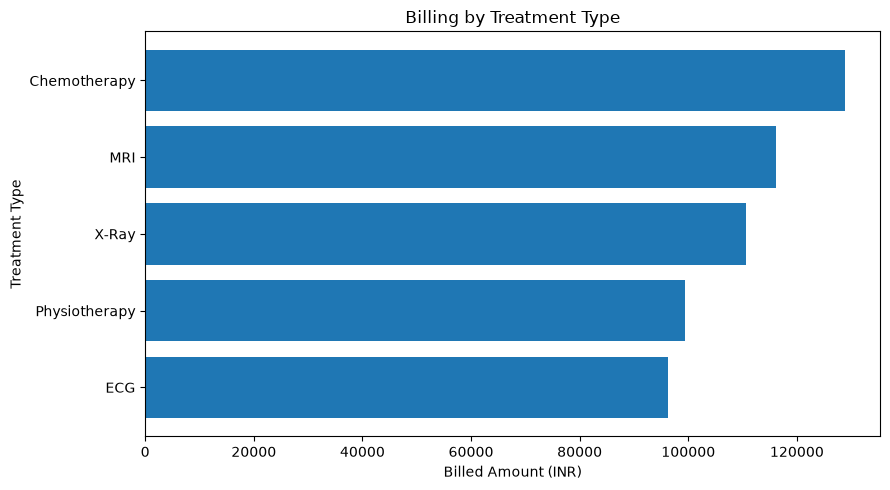

In [121]:
treatment_plot = treatment_analysis.sort_values(
    "Total_Billed_INR",
    ascending=True
)

plt.figure(figsize=(9, 5))
plt.barh(
    treatment_plot["treatment_type"],
    treatment_plot["Total_Billed_INR"]
)
plt.xlabel("Billed Amount (INR)")
plt.ylabel("Treatment Type")
plt.title("Billing by Treatment Type")
plt.tight_layout()
plt.show()


## 12. Payment Analysis

In [122]:
payment_analysis = (
    df.groupby("payment_status")
    .agg(
        Bills=("bill_id", "nunique"),
        Amount_INR=("amount", "sum"),
        Avg_Amount_INR=("amount", "mean")
    )
    .sort_values("Amount_INR", ascending=False)
    .reset_index()
)

display(payment_analysis)

payment_method_analysis = pd.crosstab(
    df["payment_method"],
    df["payment_status"]
).reset_index()

print("Payment Method vs Payment Status")
display(payment_method_analysis)


,payment_status,Bills,Amount_INR,Avg_Amount_INR
0,Failed,67,"193,212.94","2,883.78"
1,Pending,69,"184,612.01","2,675.54"
2,Paid,64,"173,424.90","2,709.76"


Payment Method vs Payment Status


payment_status,payment_method,Failed,Paid,Pending
0,Cash,23,20,18
1,Credit Card,23,24,28
2,Insurance,21,20,23


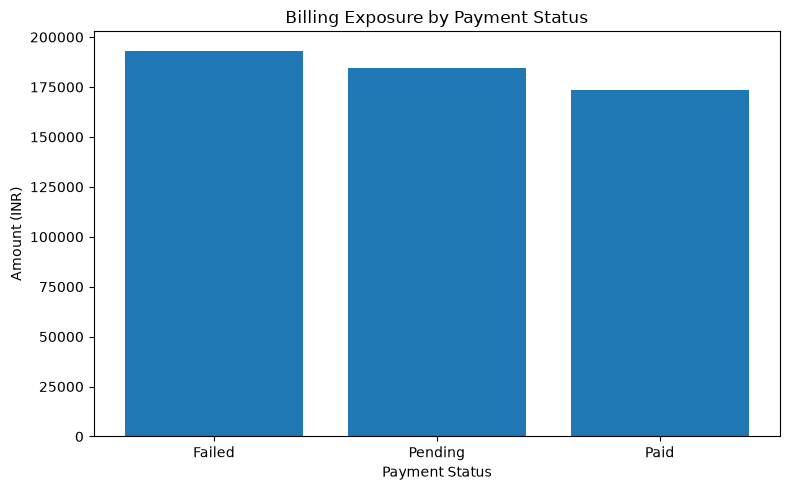

In [123]:
plt.figure(figsize=(8, 5))
plt.bar(
    payment_analysis["payment_status"],
    payment_analysis["Amount_INR"]
)
plt.xlabel("Payment Status")
plt.ylabel("Amount (INR)")
plt.title("Billing Exposure by Payment Status")
plt.tight_layout()
plt.show()


## 13. Monthly Trend Analysis

In [124]:
monthly_analysis = (
    df.groupby(
        ["appointment_month_num", "appointment_month"],
        sort=True
    )
    .agg(
        Appointments=("appointment_id", "count"),
        Completed=("status", lambda x: (x == "Completed").sum()),
        Cancelled=("status", lambda x: (x == "Cancelled").sum()),
        No_show=("status", lambda x: (x == "No-show").sum()),
        Scheduled=("status", lambda x: (x == "Scheduled").sum()),
        Billed_INR=("amount", "sum")
    )
    .reset_index()
    .sort_values("appointment_month_num")
)

monthly_analysis["Completion_Rate_%"] = (
    monthly_analysis["Completed"]
    / monthly_analysis["Appointments"]
    * 100
).round(1)

display(monthly_analysis)


,appointment_month_num,appointment_month,Appointments,Completed,Cancelled,No_show,Scheduled,Billed_INR,Completion_Rate_%
0,1,Jan,20,1,6,8,5,"58,701.23",5.00
1,2,Feb,14,6,3,3,2,"36,669.69",42.90
2,3,Mar,19,4,4,3,8,"47,304.29",21.10
3,4,Apr,25,9,7,5,4,"64,271.54",36.00
4,5,May,19,6,6,5,2,"48,791.05",31.60
5,6,Jun,18,4,2,6,6,"56,887.82",22.20
6,7,Jul,16,5,4,4,3,"39,880.19",31.20
7,8,Aug,15,3,3,3,6,"41,958.67",20.00
8,9,Sep,11,2,3,3,3,"33,426.53",18.20
9,10,Oct,14,0,5,5,4,"43,314.15",0.00


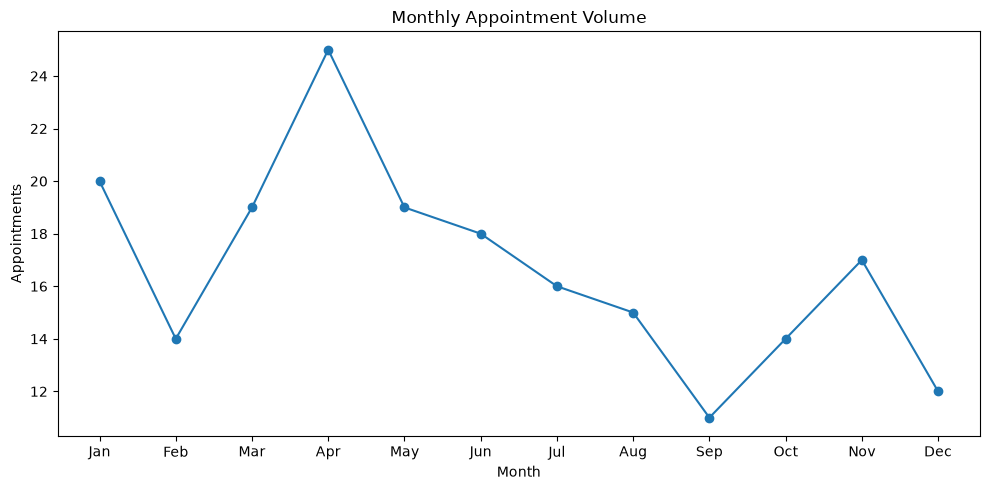

In [125]:
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_analysis["appointment_month"],
    monthly_analysis["Appointments"],
    marker="o"
)
plt.title("Monthly Appointment Volume")
plt.xlabel("Month")
plt.ylabel("Appointments")
plt.tight_layout()
plt.show()


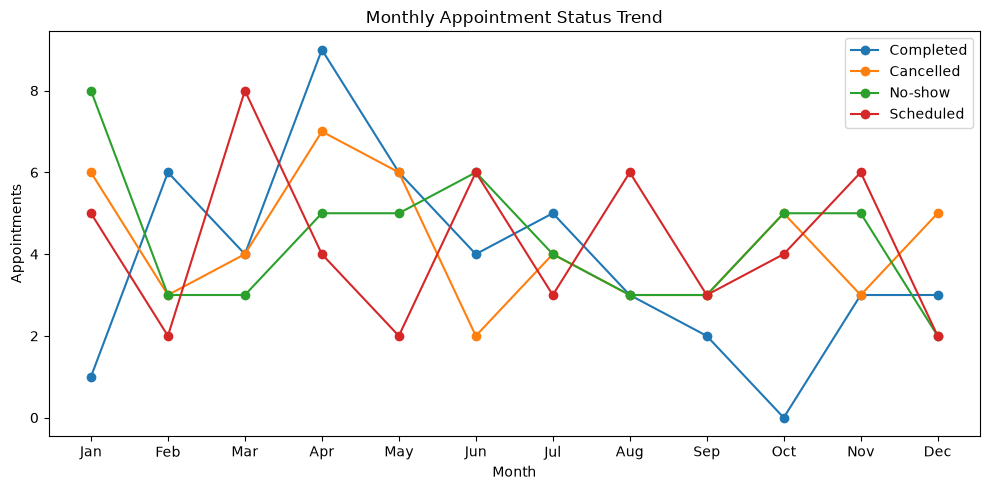

In [126]:
plt.figure(figsize=(10, 5))

for col, label in [
    ("Completed", "Completed"),
    ("Cancelled", "Cancelled"),
    ("No_show", "No-show"),
    ("Scheduled", "Scheduled")
]:
    plt.plot(
        monthly_analysis["appointment_month"],
        monthly_analysis[col],
        marker="o",
        label=label
    )

plt.title("Monthly Appointment Status Trend")
plt.xlabel("Month")
plt.ylabel("Appointments")
plt.legend()
plt.tight_layout()
plt.show()


## 14. Business Insights

In [127]:
# Identify the strongest data-backed findings

highest_no_show_branch_row = branch_analysis.loc[
    branch_analysis["No-show %"].idxmax()
]
highest_cancel_branch_row = branch_analysis.loc[
    branch_analysis["Cancelled %"].idxmax()
]
lowest_completion_reason_row = reason_analysis.loc[
    reason_analysis["Completed %"].idxmin()
]
highest_no_show_reason_row = reason_analysis.loc[
    reason_analysis["No-show %"].idxmax()
]
highest_volume_doctor_row = doctor_analysis.iloc[0]
top_treatment_row = treatment_analysis.iloc[0]

zero_completion_months = monthly_analysis.loc[
    monthly_analysis["Completed"] == 0,
    "appointment_month"
].tolist()

insights = [
    f"Appointment completion rate is {completion_rate:.1f}%, "
    f"while the no-show rate is {no_show_rate:.1f}%.",

    f"{highest_no_show_branch_row['hospital_branch']} has the highest "
    f"no-show rate at {highest_no_show_branch_row['No-show %']:.1f}%.",

    f"{highest_cancel_branch_row['hospital_branch']} has the highest "
    f"cancellation rate at {highest_cancel_branch_row['Cancelled %']:.1f}%.",

    f"{lowest_completion_reason_row['reason_for_visit']} appointments "
    f"have the lowest completion rate at "
    f"{lowest_completion_reason_row['Completed %']:.1f}%.",

    f"{highest_no_show_reason_row['reason_for_visit']} has the highest "
    f"no-show rate at {highest_no_show_reason_row['No-show %']:.1f}%.",

    f"{highest_volume_doctor_row['doctor_name']} has the highest "
    f"appointment volume with "
    f"{int(highest_volume_doctor_row['Appointments'])} appointments.",

    f"{top_treatment_row['treatment_type']} contributes the highest "
    f"billed amount at "
    f"₹{top_treatment_row['Total_Billed_INR']:,.2f}.",

    f"Month(s) with zero completed appointments: "
    f"{', '.join(zero_completion_months) if zero_completion_months else 'None'}.",

    f"Pending and failed payments together represent "
    f"₹{pending_amount + failed_amount:,.2f} in the dataset."
]

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")


1. Appointment completion rate is 23.0%, while the no-show rate is 26.0%.
2. Central Hospital has the highest no-show rate at 31.0%.
3. Westside Clinic has the highest cancellation rate at 31.5%.
4. Consultation appointments have the lowest completion rate at 9.3%.
5. Therapy has the highest no-show rate at 35.7%.
6. Sarah Taylor has the highest appointment volume with 29 appointments.
7. Chemotherapy contributes the highest billed amount at ₹128,855.68.
8. Month(s) with zero completed appointments: Oct.
9. Pending and failed payments together represent ₹377,824.95 in the dataset.


## 15. Recommended Business Actions

In [128]:
recommendations = [
    f"Review appointment processes at "
    f"{highest_no_show_branch_row['hospital_branch']}, where the "
    f"no-show rate is {highest_no_show_branch_row['No-show %']:.1f}%.",

    f"Investigate the workflow for "
    f"{lowest_completion_reason_row['reason_for_visit']} appointments "
    f"because their completion rate is "
    f"{lowest_completion_reason_row['Completed %']:.1f}%.",

    f"Consider stronger appointment confirmation and reminder "
    f"processes for {highest_no_show_reason_row['reason_for_visit']} "
    f"appointments, which have a "
    f"{highest_no_show_reason_row['No-show %']:.1f}% no-show rate.",

    f"Review workload distribution because "
    f"{highest_volume_doctor_row['doctor_name']} handles "
    f"{int(highest_volume_doctor_row['Appointments'])} appointments.",

    f"Prioritize follow-up of pending and failed payments, which "
    f"represent ₹{pending_amount + failed_amount:,.2f} combined "
    f"in this dataset.",

    f"Track {top_treatment_row['treatment_type']} billing closely "
    f"because it contributes the largest billed amount."
]

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")


1. Review appointment processes at Central Hospital, where the no-show rate is 31.0%.
2. Investigate the workflow for Consultation appointments because their completion rate is 9.3%.
3. Consider stronger appointment confirmation and reminder processes for Therapy appointments, which have a 35.7% no-show rate.
4. Review workload distribution because Sarah Taylor handles 29 appointments.
5. Prioritize follow-up of pending and failed payments, which represent ₹377,824.95 combined in this dataset.
6. Track Chemotherapy billing closely because it contributes the largest billed amount.


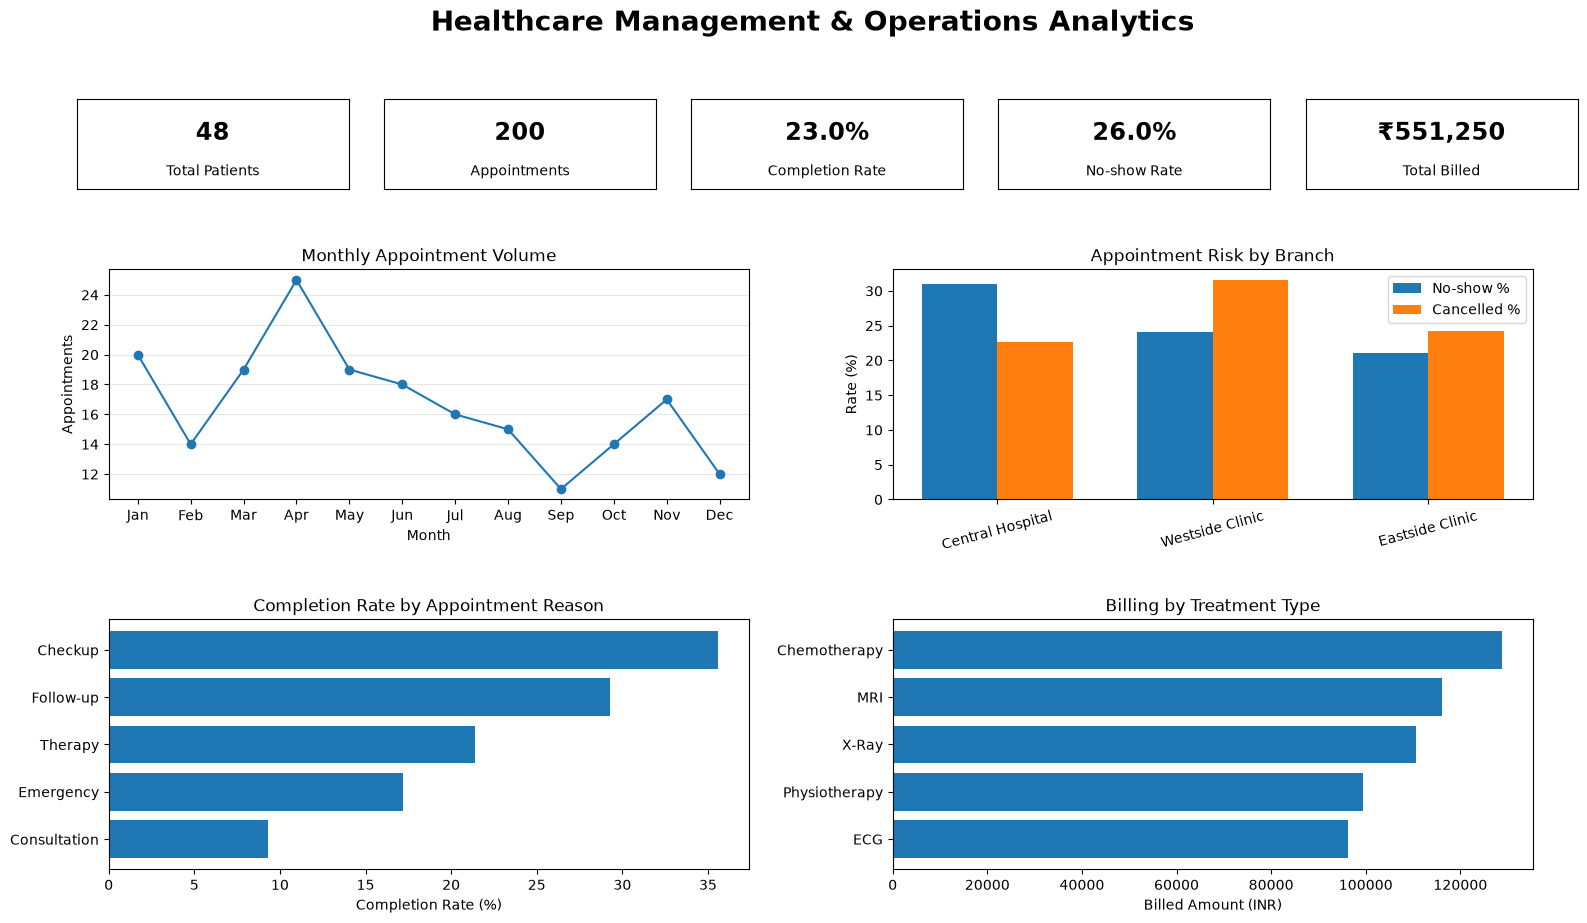

In [129]:
# Executive dashboard

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    "Healthcare Management & Operations Analytics",
    fontsize=20,
    fontweight="bold"
)

# KPI cards
kpi_cards = [
    ("Total Patients", f"{df['patient_id'].nunique()}"),
    ("Appointments", f"{len(df)}"),
    ("Completion Rate", f"{completion_rate:.1f}%"),
    ("No-show Rate", f"{no_show_rate:.1f}%"),
    ("Total Billed", f"₹{total_billed:,.0f}")
]

for i, (label, value) in enumerate(kpi_cards):
    ax = fig.add_axes([0.04 + i * 0.192, 0.80, 0.17, 0.09])
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)

    ax.text(
        0.5, 0.62, value,
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold"
    )
    ax.text(
        0.5, 0.20, label,
        ha="center",
        va="center",
        fontsize=10
    )

# Monthly volume
ax1 = fig.add_axes([0.06, 0.49, 0.40, 0.23])
ax1.plot(
    monthly_analysis["appointment_month"],
    monthly_analysis["Appointments"],
    marker="o"
)
ax1.set_title("Monthly Appointment Volume")
ax1.set_xlabel("Month")
ax1.set_ylabel("Appointments")
ax1.grid(axis="y", alpha=0.3)

# Branch risk
ax2 = fig.add_axes([0.55, 0.49, 0.40, 0.23])
branch_plot = branch_analysis.sort_values("No-show %", ascending=False)

x = np.arange(len(branch_plot))
width = 0.35

ax2.bar(
    x - width / 2,
    branch_plot["No-show %"],
    width,
    label="No-show %"
)
ax2.bar(
    x + width / 2,
    branch_plot["Cancelled %"],
    width,
    label="Cancelled %"
)

ax2.set_xticks(x)
ax2.set_xticklabels(
    branch_plot["hospital_branch"],
    rotation=15
)
ax2.set_ylabel("Rate (%)")
ax2.set_title("Appointment Risk by Branch")
ax2.legend()

# Reason completion
ax3 = fig.add_axes([0.06, 0.12, 0.40, 0.25])
reason_plot = reason_analysis.sort_values("Completed %")

ax3.barh(
    reason_plot["reason_for_visit"],
    reason_plot["Completed %"]
)
ax3.set_xlabel("Completion Rate (%)")
ax3.set_title("Completion Rate by Appointment Reason")

# Treatment billing
ax4 = fig.add_axes([0.55, 0.12, 0.40, 0.25])
treatment_plot = treatment_analysis.sort_values("Total_Billed_INR")

ax4.barh(
    treatment_plot["treatment_type"],
    treatment_plot["Total_Billed_INR"]
)
ax4.set_xlabel("Billed Amount (INR)")
ax4.set_title("Billing by Treatment Type")

plt.show()


## 17. Export Analysis Outputs

In [130]:
output_dir = Path("healthcare_outputs")
output_dir.mkdir(exist_ok=True)

outputs = {
    "kpi_summary.csv": kpi_summary,
    "status_analysis.csv": status_summary,
    "branch_analysis.csv": branch_analysis,
    "reason_analysis.csv": reason_analysis,
    "specialization_analysis.csv": specialization_analysis,
    "doctor_analysis.csv": doctor_analysis,
    "treatment_analysis.csv": treatment_analysis,
    "payment_analysis.csv": payment_analysis,
    "payment_method_analysis.csv": payment_method_analysis,
    "monthly_analysis.csv": monthly_analysis,
    "business_insights.csv": pd.DataFrame({"Insight": insights}),
    "recommendations.csv": pd.DataFrame({"Recommendation": recommendations})
}

for filename, table in outputs.items():
    table.to_csv(output_dir / filename, index=False)

print(f"Analysis outputs saved to: {output_dir.resolve()}")


Analysis outputs saved to: D:\IBM Skillbuild Data Analytics\Healthcare_Analytics\healthcare_outputs


## 18. Final Project Summary

The project converts the hospital management dataset into management-oriented information by moving from KPIs to trends, drivers, operational risks, financial exposure, and recommended actions.

### Key Scope
- Appointment performance
- Branch-level operational patterns
- Appointment-reason analysis
- Specialization analysis
- Doctor workload
- Treatment billing
- Payment exposure
- Monthly trends
- Business insights and recommendations

### Dataset Limitation
The dataset is synthetic and does not contain clinical outcomes, patient satisfaction, waiting time, bed utilization, length of stay, or readmission information. Therefore, this project does not make claims about those measures.


# Interactive Frontend — Healthcare Operations Dashboard

This section adds the interactive frontend to the same notebook. The existing data preparation and analytics cells act as the backend, while the widgets and Plotly charts below provide the user-facing dashboard.


In [131]:
# Frontend dependencies
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output

# Use the prepared appointment-level dataset created earlier in this notebook.
# If the notebook is opened independently, load the exported analysis-ready CSV.
if 'analysis_df' not in globals():
    analysis_df = pd.read_csv('healthcare_analysis_ready.csv')
    for col in ['appointment_date', 'treatment_date', 'bill_date']:
        if col in analysis_df.columns:
            analysis_df[col] = pd.to_datetime(analysis_df[col], errors='coerce')

analysis_df['appointment_month'] = analysis_df['appointment_date'].dt.strftime('%b')
analysis_df['appointment_month_num'] = analysis_df['appointment_date'].dt.month
analysis_df['patient_name'] = analysis_df['first_name'] + ' ' + analysis_df['last_name']
analysis_df['doctor_name'] = analysis_df['first_name_doctor'] + ' ' + analysis_df['last_name_doctor']

print('Interactive frontend loaded successfully.')


Interactive frontend loaded successfully.


In [132]:
# Lightweight interactive frontend
# Uses ipywidgets + Matplotlib to keep the notebook fast in VS Code.

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

branch_widget = widgets.Dropdown(
    options=['All'] + sorted(analysis_df['hospital_branch'].dropna().unique()),
    description='Branch:'
)
status_widget = widgets.Dropdown(
    options=['All'] + sorted(analysis_df['status'].dropna().unique()),
    description='Status:'
)
specialization_widget = widgets.Dropdown(
    options=['All'] + sorted(analysis_df['specialization'].dropna().unique()),
    description='Specialty:'
)

apply_button = widgets.Button(description='Apply Filters')
reset_button = widgets.Button(description='Reset')
output = widgets.Output()

def get_filtered_data():
    df = analysis_df
    if branch_widget.value != 'All':
        df = df[df['hospital_branch'].eq(branch_widget.value)]
    if status_widget.value != 'All':
        df = df[df['status'].eq(status_widget.value)]
    if specialization_widget.value != 'All':
        df = df[df['specialization'].eq(specialization_widget.value)]
    return df

def show_frontend(_=None):
    df = get_filtered_data()

    with output:
        clear_output(wait=True)

        if df.empty:
            print("No records match the selected filters.")
            return

        total = len(df)
        completed = int(df['status'].eq('Completed').sum())
        no_show = int(df['status'].eq('No-show').sum())
        cancelled = int(df['status'].eq('Cancelled').sum())
        billed = df['cost'].sum()
        completion_rate = completed / total * 100

        print("HEALTHCARE OPERATIONS DASHBOARD")
        print("=" * 38)
        print(f"Appointments : {total}")
        print(f"Completed    : {completed}")
        print(f"Completion % : {completion_rate:.1f}%")
        print(f"No-shows     : {no_show}")
        print(f"Cancelled    : {cancelled}")
        print(f"Billed Value : ₹{billed:,.2f}")
        print()

        monthly = (
            df.groupby(['appointment_month_num', 'appointment_month'])
              .size()
              .reset_index(name='appointments')
              .sort_values('appointment_month_num')
        )

        plt.figure(figsize=(9, 4))
        plt.plot(monthly['appointment_month'], monthly['appointments'], marker='o')
        plt.title('Monthly Appointment Volume')
        plt.xlabel('Month')
        plt.ylabel('Appointments')
        plt.tight_layout()
        plt.show()

        branch = df.groupby('hospital_branch').size().sort_values(ascending=False)

        plt.figure(figsize=(8, 4))
        branch.plot(kind='bar')
        plt.title('Appointments by Branch')
        plt.xlabel('Hospital Branch')
        plt.ylabel('Appointments')
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()

        print("Top treatment billing:")
        treatment = (
            df.groupby('treatment_type')['cost']
              .sum()
              .sort_values(ascending=False)
              .head(5)
              .round(2)
        )
        display(treatment.to_frame('Billed Value (₹)'))

def reset_filters(_):
    branch_widget.value = 'All'
    status_widget.value = 'All'
    specialization_widget.value = 'All'
    show_frontend()

apply_button.on_click(show_frontend)
reset_button.on_click(reset_filters)

display(widgets.HBox([branch_widget, status_widget, specialization_widget]))
display(widgets.HBox([apply_button, reset_button]))
display(output)

# Render only once after the user explicitly clicks Apply.
print("Select filters, then click 'Apply Filters'.")


Output()

Select filters, then click 'Apply Filters'.


### Frontend/Backend Structure
- **Backend:** CSV ingestion, cleaning, joins, KPI calculations, driver analysis, billing analysis, and business insights are implemented in the earlier notebook cells.
- **Frontend:** The interactive section above provides branch, status, and specialization filters, KPI cards, interactive Plotly charts, reset controls, and a filtered appointment table.
- **ML:** No prediction model is added because the available dataset does not provide a strong basis for a meaningful predictive objective; the project remains focused on actionable analytics.


# Executive Healthcare Analytics Dashboard

Interactive presentation layer for the healthcare operations analysis.

**Flow:** Filters → KPIs → Appointment Status → Monthly Trend → Branch Performance → Billing by Treatment


In [133]:
# Interactive Healthcare Analytics Dashboard

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, HTML
import ipywidgets as widgets

# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
try:
    df_dashboard = df.copy()
except NameError:
    df_dashboard = pd.read_csv("healthcare_analysis_ready.csv")

df_dashboard["appointment_date"] = pd.to_datetime(
    df_dashboard["appointment_date"],
    errors="coerce"
)

# Column names
branch_col = "hospital_branch"
status_col = "status"
specialization_col = "specialization"
treatment_col = "treatment_type"
cost_col = "cost"
date_col = "appointment_date"


# ---------------------------------------------------------
# FILTER CONTROLS
# ---------------------------------------------------------
branch_dd = widgets.Dropdown(
    options=["All"] + sorted(
        df_dashboard[branch_col].dropna().astype(str).unique().tolist()
    ),
    value="All",
    description="Branch:"
)

status_dd = widgets.Dropdown(
    options=["All"] + sorted(
        df_dashboard[status_col].dropna().astype(str).unique().tolist()
    ),
    value="All",
    description="Status:"
)

specialty_dd = widgets.Dropdown(
    options=["All"] + sorted(
        df_dashboard[specialization_col].dropna().astype(str).unique().tolist()
    ),
    value="All",
    description="Specialty:"
)

apply_btn = widgets.Button(
    description="Apply Filters",
    button_style="primary",
    icon="filter"
)

reset_btn = widgets.Button(
    description="Reset",
    icon="refresh"
)

output = widgets.Output()


# ---------------------------------------------------------
# HELPER FUNCTIONS
# ---------------------------------------------------------
def money(value):
    return f"Rs. {value:,.2f}"


def card(title, value):
    return f"""
    <div style="
        border:1px solid #d5d5d5;
        border-radius:12px;
        padding:14px 12px;
        background:#ffffff;
        box-sizing:border-box;
        height:100px;
        display:flex;
        flex-direction:column;
        justify-content:center;
        text-align:center;
    ">
        <div style="
            font-size:12px;
            color:#666;
            margin-bottom:7px;
            white-space:nowrap;
        ">
            {title}
        </div>

        <div style="
            font-size:21px;
            font-weight:700;
            color:#111;
            white-space:nowrap;
        ">
            {value}
        </div>
    </div>
    """


# ---------------------------------------------------------
# DASHBOARD
# ---------------------------------------------------------
def render_dashboard(_=None):

    with output:

        clear_output(wait=True)

        d = df_dashboard.copy()

        # Apply filters
        if branch_dd.value != "All":
            d = d[
                d[branch_col].astype(str) == branch_dd.value
            ]

        if status_dd.value != "All":
            d = d[
                d[status_col].astype(str) == status_dd.value
            ]

        if specialty_dd.value != "All":
            d = d[
                d[specialization_col].astype(str) == specialty_dd.value
            ]


        # -------------------------------------------------
        # KPI CALCULATIONS
        # -------------------------------------------------
        total = len(d)

        completed = int(
            (d[status_col] == "Completed").sum()
        )

        cancelled = int(
            (d[status_col] == "Cancelled").sum()
        )

        no_show = int(
            (d[status_col] == "No-show").sum()
        )

        billed = d[cost_col].sum()

        def percentage(value):
            if total == 0:
                return 0
            return value / total * 100


        # -------------------------------------------------
        # DASHBOARD HEADER
        # -------------------------------------------------
        display(
            HTML("""
            <div style="
                padding:5px 0 12px 0;
                font-family:Arial,sans-serif;
            ">

                <h1 style="
                    margin:0;
                    font-size:30px;
                ">
                    Healthcare Analytics Dashboard
                </h1>

                <p style="
                    margin:5px 0 0 0;
                    color:#666;
                    font-size:15px;
                ">
                    Hospital operations, appointment performance and billing overview
                </p>

            </div>
            """)
        )


        # -------------------------------------------------
        # KPI CARDS - ALWAYS ONE ROW
        # -------------------------------------------------
        kpi_html = f"""
        <div style="
            display:grid;
            grid-template-columns:repeat(6, minmax(0, 1fr));
            gap:10px;
            width:100%;
            margin-bottom:18px;
        ">

            {card("Total Appointments", f"{total:,}")}

            {card("Completed", f"{completed:,}")}

            {card(
                "Completion Rate",
                f"{percentage(completed):.1f}%"
            )}

            {card(
                "Cancellation Rate",
                f"{percentage(cancelled):.1f}%"
            )}

            {card(
                "No-show Rate",
                f"{percentage(no_show):.1f}%"
            )}

            {card(
                "Total Billed",
                money(billed)
            )}

        </div>
        """

        display(HTML(kpi_html))


        # -------------------------------------------------
        # EMPTY DATA CHECK
        # -------------------------------------------------
        if d.empty:

            display(
                HTML("""
                <div style="
                    padding:20px;
                    border:1px solid #ddd;
                    border-radius:10px;
                    text-align:center;
                ">
                    <h3>No records match the selected filters.</h3>
                </div>
                """)
            )

            return


        # -------------------------------------------------
        # APPOINTMENT STATUS
        # -------------------------------------------------
        plt.figure(figsize=(9, 4.5))

        d[status_col].value_counts().plot(
            kind="bar"
        )

        plt.title(
            "Appointment Status",
            fontsize=15
        )

        plt.xlabel("Status")
        plt.ylabel("Appointments")

        plt.xticks(rotation=0)

        plt.tight_layout()

        plt.show()


        # -------------------------------------------------
        # MONTHLY APPOINTMENT TREND
        # -------------------------------------------------
        monthly = (
            d.assign(
                month=d[date_col]
                .dt.to_period("M")
                .astype(str)
            )
            .groupby("month")
            .size()
        )

        plt.figure(figsize=(9, 4.5))

        monthly.plot(
            kind="line",
            marker="o"
        )

        plt.title(
            "Monthly Appointment Trend",
            fontsize=15
        )

        plt.xlabel("Month")
        plt.ylabel("Appointments")

        plt.xticks(rotation=45)

        plt.tight_layout()

        plt.show()


        # -------------------------------------------------
        # BRANCH PERFORMANCE
        # -------------------------------------------------
        branch = (
            d[branch_col]
            .value_counts()
            .sort_values(ascending=False)
        )

        plt.figure(figsize=(9, 4.5))

        branch.plot(
            kind="bar"
        )

        plt.title(
            "Appointments by Hospital Branch",
            fontsize=15
        )

        plt.xlabel("Hospital Branch")
        plt.ylabel("Appointments")

        plt.xticks(
            rotation=20,
            ha="right"
        )

        plt.tight_layout()

        plt.show()


        # -------------------------------------------------
        # BILLING BY TREATMENT
        # -------------------------------------------------
        billing = (
            d.groupby(treatment_col)[cost_col]
            .agg(
                Treatments="count",
                Total_Billed="sum",
                Average_Cost="mean"
            )
            .sort_values(
                "Total_Billed",
                ascending=False
            )
        )

        display(
            HTML("""
            <h3 style="
                margin-top:15px;
                margin-bottom:8px;
            ">
                Billing by Treatment Type
            </h3>
            """)
        )

        display(
            billing.style.format({
                "Total_Billed": "Rs. {:,.2f}",
                "Average_Cost": "Rs. {:,.2f}"
            })
        )


# ---------------------------------------------------------
# RESET
# ---------------------------------------------------------
def reset_dashboard(_=None):

    branch_dd.value = "All"
    status_dd.value = "All"
    specialty_dd.value = "All"

    render_dashboard()


# ---------------------------------------------------------
# BUTTON EVENTS
# ---------------------------------------------------------
apply_btn.on_click(render_dashboard)
reset_btn.on_click(reset_dashboard)


# ---------------------------------------------------------
# DISPLAY FILTERS + DASHBOARD
# ---------------------------------------------------------
filter_box = widgets.HBox(
    [
        branch_dd,
        status_dd,
        specialty_dd,
        apply_btn,
        reset_btn
    ],
    layout=widgets.Layout(
        width="100%",
        margin="0 0 15px 0"
    )
)

display(filter_box)

display(output)

render_dashboard()

Output()